##Resources Used:


*   https://www.tensorflow.org/api_docs/python/tf/keras/layers
*   https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier
*   https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
*   https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
*   https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

*   https://numpy.org/doc/stable/reference/generated/numpy.concatenate.html
*   https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html
*   https://www.tensorflow.org/api_docs/python/tf/keras/Sequential
*   https://stackoverflow.com/questions/56202923/parsiing-df-column-having-multiple-comma-separated-labels-into-the-individual-co
*   https://www.rexegg.com/regex-quickstart.html
*   https://scikit-learn.org/stable/modules/impute.html
*   https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html
*   https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html#sklearn.metrics.precision_recall_fscore_support
*   https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

#Import Packages

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

import sklearn
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_fscore_support, accuracy_score

import time

#Model Flags


In [73]:
RF_flag=True
KNN_flag=True
NB_flag=True
DNN_flag=True
WNN_flag=True

#Load and Prepare Data

In [121]:
#Load Train CSV File and check shape
#Drop any entries with a blank column

df = pd.read_csv('/content/drive/MyDrive/Boeing Data Science Challenge Problem V2/Training_DataSet.csv').set_index('ListingID').sample(frac=1).ffill()
print(f"Original df Shape: {df.shape}")

#Get Columns to make Features out of
useful_feature_columns = ['SellerCity',
                          'SellerListSrc',
                          'SellerName',
                          'SellerRating',
                          #'SellerRevCnt',
                          'SellerState',
                          'VehBodystyle',
                          'VehColorExt',
                          'VehColorInt',
                          'VehDriveTrain',
                          'VehEngine',
                         # 'VehFeats',
                          'VehFuel',
                          'VehHistory',
                          'VehListdays',
                          'VehMake',
                          'VehMileage',
                          'VehModel',
                          'VehPriceLabel',
                          #'VehSellerNotes',
                          'VehType',
                          'VehTransmission',
                          'VehYear',
                          'Vehicle_Trim', 'Dealer_Listing_Price' #Labels
                          ]

#Pull out Veh Feats aside for string parsing
veh_feats = df['VehFeats']

#Turn vehicle year into a categorical feature and not regressional
df['VehYear'] = df['VehYear'].astype(str)

df = df[useful_feature_columns]
print(f"Filtered df shape: {df.shape}")

#One Hot Encode String and Boolean Categorical Columns
feat_enc=OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=50)
categorical_columns = df.select_dtypes(include=['object', 'boolean']).iloc[:,:-1]
categorical_features = feat_enc.fit_transform(categorical_columns).toarray()

#Split df to have 85% of data for training and 15% for validation
train_split=0.85
train_samples = int(len(df)*train_split)

train_df = df[:train_samples]
train_cat_features = categorical_features[:train_samples]

val_df = df[train_samples:]
val_cat_features = categorical_features[train_samples:]


print(f"train_df shape: {train_df.shape}")
print(f"val_df shape: {val_df.shape}")

#Encode Categorical Labels (One Hot for NNs and Numerical for Classical ML)
oh_lab_enc=OneHotEncoder()
le_lab_enc = LabelEncoder()

categorical_labels_one_hot = oh_lab_enc.fit_transform(df['Vehicle_Trim'].to_frame()).toarray()
categorical_labels_enc = le_lab_enc.fit_transform(df['Vehicle_Trim'].to_frame().squeeze())

regression_labels = df['Dealer_Listing_Price']

#Train and Validation Split
train_categorical_labels_one_hot = categorical_labels_one_hot[:train_samples]
train_categorical_labels_enc = categorical_labels_enc[:train_samples]
train_regression_labels = regression_labels[:train_samples]

val_categorical_labels_one_hot = categorical_labels_one_hot[train_samples:]
val_categorical_labels_enc = categorical_labels_enc[train_samples:]
val_regression_labels = regression_labels[train_samples:]

#Filter out Labels from split dfs for regressional feature encoding
train_df = train_df.loc[:, ~train_df.columns.isin(['Vehicle_Trim', 'Dealer_Listing_Price'])]
val_df = val_df.loc[:, ~val_df.columns.isin(['Vehicle_Trim', 'Dealer_Listing_Price'])]


#View a portion of the df
#print(val_df.head())

Original df Shape: (6298, 28)
Filtered df shape: (6298, 22)
train_df shape: (5353, 22)
val_df shape: (945, 22)


In [105]:
def get_veh_feat_encodings(veh_feats):
  #Split String Column to individual strings for each vehicle feature
  veh_feats = veh_feats.str.split(',')

  #Make a new df based on the unique separate feature values from the step above
  veh_feats_array = veh_feats.apply(pd.Series)

  #One Hot Encode the features and return only the most preeminent ones
  veh_one_hot = OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=100)
  encoding = veh_one_hot.fit_transform(veh_feats_array).toarray()

  #Return the encoder for transforming test set features, as well as the encodings for train and val sets
  return veh_one_hot, encoding

veh_one_hot, veh_feat_encoding = get_veh_feat_encodings(veh_feats)
print(f"Shape of Vehicle Feature Encodings for Train and Val Sets: {veh_feat_encoding.shape}")
veh_feat_encoding_train = veh_feat_encoding[:train_samples]
veh_feat_encoding_val = veh_feat_encoding[train_samples:]

Shape of Vehicle Feature Encodings for Train and Val Sets: (6298, 111)


In [106]:
#Prepare features for ML
def get_features(feature_df, categorical_features, veh_features):

  ###################Regressional Features###################
  regressional_columns = feature_df.select_dtypes(exclude=['object','boolean'])
  scaler = MinMaxScaler()
  scaler.fit(regressional_columns)

  ###################Output the Features###################
  regressional_features = scaler.transform(regressional_columns)
  all_features = np.concatenate((regressional_features,categorical_features, veh_features), axis=1)

  #print("FEATURES:\n")
  #print(all_features)
  print(f"Regressional Features Shape: {regressional_features.shape}, Categorical Features Shape: {categorical_features.shape}, Vehicle Features Shape: {veh_features.shape}, Concatenated Shape of All Features: {all_features.shape}")
  return all_features

train_features = get_features(train_df, train_cat_features, veh_feat_encoding_train)

Regressional Features Shape: (5353, 3), Categorical Features Shape: (5353, 150), Vehicle Features Shape: (5353, 111), Concatenated Shape of All Features: (5353, 264)


#Testing ML Models (Regression)

##Random Forest

In [107]:
#Random Forest Regressor
if RF_flag:
  time_now = time.time()

  random_forest_regression = RandomForestRegressor()
  random_forest_regression.fit(train_features, train_regression_labels)

  print(f"Random Forest Train Time: {(time.time()-time_now)/60 :.2f} minutes")

Random Forest Train Time: 0.17 minutes


##K-Nearest Neighbors

In [108]:
#K-Nearest Neighbors Regressor
if KNN_flag:
  time_now = time.time()

  knn_regression = KNeighborsRegressor(n_neighbors=4)
  knn_regression.fit(train_features, train_regression_labels)

  print(f"K Nearest Neighbors Train Time: {(time.time()-time_now)/60 :.2f} minutes")

K Nearest Neighbors Train Time: 0.00 minutes


##Naive Bayes

In [109]:
#Naive Bayes Regressor
if NB_flag:
  time_now = time.time()

  naive_bayes_regression = GaussianNB()
  naive_bayes_regression.fit(train_features, train_regression_labels)

  print(f"Naive Bayes Train Time: {(time.time()-time_now)/60 :.2f} minutes")

Naive Bayes Train Time: 0.00 minutes


## Deep Neural Network

In [110]:
#Deep Regressional Neural Network
if DNN_flag:
  time_now = time.time()

  deep_neural_network_regression = Sequential([
                                Dense(2048, input_shape=[train_features.shape[1]], activation='relu'),
                                Dropout(0.30),

                                Dense(1024,activation='relu'),

                                Dense(512,activation='relu'),

                                Dense(256, activation='relu'),

                                Dense(128,activation='relu'),

                                Dense(32, activation='relu'),

                                Dense(1)
                                ])

  deep_neural_network_regression.compile(optimizer='adam', loss='huber', metrics='mae')
  deep_neural_network_regression.fit(train_features, train_regression_labels,batch_size=256, epochs=50, verbose=1)

  print(f"Deep Neural Net Train Time: {(time.time()-time_now)/60 :.2f} minutes")

Epoch 1/50
21/21 [==============================] - 3s 7ms/step - loss: 28311.1680 - mae: 28311.6660
Epoch 2/50
21/21 [==============================] - 0s 7ms/step - loss: 7024.3071 - mae: 7024.8071
Epoch 3/50
21/21 [==============================] - 0s 6ms/step - loss: 3810.9016 - mae: 3811.4014
Epoch 4/50
21/21 [==============================] - 0s 6ms/step - loss: 2825.5811 - mae: 2826.0811
Epoch 5/50
21/21 [==============================] - 0s 6ms/step - loss: 2555.5869 - mae: 2556.0869
Epoch 6/50
21/21 [==============================] - 0s 6ms/step - loss: 2489.7734 - mae: 2490.2734
Epoch 7/50
21/21 [==============================] - 0s 7ms/step - loss: 2383.1133 - mae: 2383.6135
Epoch 8/50
21/21 [==============================] - 0s 6ms/step - loss: 2303.4211 - mae: 2303.9214
Epoch 9/50
21/21 [==============================] - 0s 6ms/step - loss: 2188.5181 - mae: 2189.0178
Epoch 10/50
21/21 [==============================] - 0s 6ms/step - loss: 2108.5684 - mae: 2109.0681
Epoch 1

##Wide Neural Network

In [111]:
#Wide Regressional Neural Network
if WNN_flag:
  time_now = time.time()

  wide_neural_network_regression = Sequential([
                                Dense(train_features.shape[1], input_shape=[train_features.shape[1]], activation='relu'),
                                Dense(1)
                                ])

  wide_neural_network_regression.compile(optimizer='adam', loss='huber', metrics='mae')
  wide_neural_network_regression.fit(train_features, train_regression_labels,batch_size=256, epochs=50, verbose=1)

  print(f"Wide Neural Net Train Time: {(time.time()-time_now)/60 :.2f} minutes")

Epoch 1/50
21/21 [==============================] - 1s 5ms/step - loss: 32302.7988 - mae: 32303.2969
Epoch 2/50
21/21 [==============================] - 0s 5ms/step - loss: 32291.1895 - mae: 32291.6875
Epoch 3/50
21/21 [==============================] - 0s 5ms/step - loss: 32271.9277 - mae: 32272.4277
Epoch 4/50
21/21 [==============================] - 0s 5ms/step - loss: 32243.3320 - mae: 32243.8320
Epoch 5/50
21/21 [==============================] - 0s 5ms/step - loss: 32204.2227 - mae: 32204.7207
Epoch 6/50
21/21 [==============================] - 0s 5ms/step - loss: 32153.9258 - mae: 32154.4258
Epoch 7/50
21/21 [==============================] - 0s 5ms/step - loss: 32091.8340 - mae: 32092.3320
Epoch 8/50
21/21 [==============================] - 0s 5ms/step - loss: 32017.7480 - mae: 32018.2500
Epoch 9/50
21/21 [==============================] - 0s 5ms/step - loss: 31931.5918 - mae: 31932.0938
Epoch 10/50
21/21 [==============================] - 0s 5ms/step - loss: 31833.2949 - mae: 

#Metrics

##Evaluate Results

In [112]:
def regression_eval(df_entrys, labels, ml_model, nn=False):
  percentages_array = []
  predictions_array = []

#Predict and Print for first 10 in the provided df of features
  for index, features in enumerate(df_entrys[:10]):
    features = np.expand_dims(features, 0)
    prediction = ml_model.predict(features)[0]
    if nn:
      prediction=prediction[0]
    actual = labels.iloc[index]
    error = np.abs(prediction-actual)
    error_percentage = error/actual*100
    print(f"Prediction: ${prediction :,.0f}  Actual: ${actual :,.0f} Error: ${error :,.0f}, Error Percentage: {error_percentage :.1f}% ")

#Predict and for all entrys in the provided df of features
#Then return the predictions and the average error percentage
  for index, features in enumerate(df_entrys):
    features = np.expand_dims(features, 0)
    prediction = ml_model.predict(features)[0]
    if nn:
      prediction=prediction[0]
    predictions_array.append(prediction)
    actual = labels.iloc[index]
    error = np.abs(prediction-actual)
    error_percentage = error/actual*100
    percentages_array.append(error_percentage)
  return predictions_array, np.mean(percentages_array)


In [113]:
  ###################VALIDATION SET RESULTS###################

print("Validation Set:")
val_features = get_features(val_df, val_cat_features, veh_feat_encoding_val)

if RF_flag:
    print("\nRANDOM FOREST:")
    random_forest_predictions, random_forest_error = regression_eval(val_features, val_regression_labels, random_forest_regression)

if KNN_flag:
    print("\nK NEAREST NEIGHBORS:")
    knn_predictions, knn_error= regression_eval(val_features, val_regression_labels, knn_regression)

if NB_flag:
    print("\nNAIVE BAYES:")
    naive_bayes_predictions, naive_bayes_error = regression_eval(val_features, val_regression_labels, naive_bayes_regression)

if DNN_flag:
    print("\nDEEP NEURAL NETWORK:")
    deep_neural_network_predictions, deep_neural_network_error  = regression_eval(val_features, val_regression_labels, deep_neural_network_regression, nn=True)

if WNN_flag:
    print("\nWIDE NEURAL NETWORK:")
    wide_neural_network_predictions, wide_neural_network_error = regression_eval(val_features, val_regression_labels, wide_neural_network_regression, nn=True)

if RF_flag:
    print(f"Mean Error Percentage for Random Forest: {random_forest_error :,.0f}%")
if KNN_flag:
    print(f"Mean Error Percentage for K Nearest Neighbors: {knn_error :,.0f}%")
if NB_flag:
    print(f"Mean Error Percentage for Naive Bayes: {naive_bayes_error :,.0f}%")
if DNN_flag:
    print(f"Mean Error Percentage for Deep Neural Network: {deep_neural_network_error :,.0f}%")
if WNN_flag:
    print(f"Mean Error Percentage for Wide Neural Network: {wide_neural_network_error :,.0f}%")

Validation Set:
Regressional Features Shape: (945, 3), Categorical Features Shape: (945, 150), Vehicle Features Shape: (945, 111), Concatenated Shape of All Features: (945, 264)

RANDOM FOREST:
Prediction: $29,161  Actual: $30,990 Error: $1,829, Error Percentage: 5.9% 
Prediction: $26,285  Actual: $27,483 Error: $1,198, Error Percentage: 4.4% 
Prediction: $36,014  Actual: $37,234 Error: $1,220, Error Percentage: 3.3% 
Prediction: $23,648  Actual: $23,998 Error: $350, Error Percentage: 1.5% 
Prediction: $35,436  Actual: $38,993 Error: $3,557, Error Percentage: 9.1% 
Prediction: $32,355  Actual: $38,723 Error: $6,368, Error Percentage: 16.4% 
Prediction: $33,897  Actual: $34,498 Error: $601, Error Percentage: 1.7% 
Prediction: $23,827  Actual: $25,950 Error: $2,123, Error Percentage: 8.2% 
Prediction: $41,066  Actual: $33,085 Error: $7,981, Error Percentage: 24.1% 
Prediction: $23,489  Actual: $23,300 Error: $189, Error Percentage: 0.8% 

K NEAREST NEIGHBORS:
Prediction: $37,560  Actual:

##Plot Results

Regression Confusion Matrix Plot: If every prediction is correct, every scatter point will sit on the y=x red line


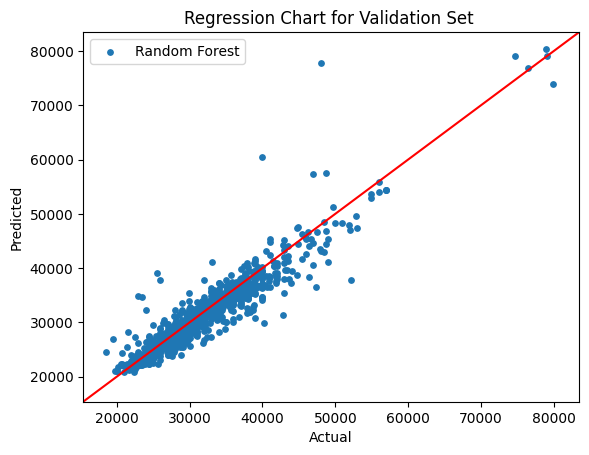

In [118]:
def plot_predicted_vs_actual(predicted, actual, model_name):
  plt.Figure(figsize=(12,8))
  #Scatter points based on the predicted and actual values of the data
  plt.scatter(actual, predicted, label=model_name, s=15)

  #Plot a Y=X Guide Line to see model accuracy
  min_val = min((min(predicted), min(actual)))
  max_val = max((max(predicted), max(actual)))
  plt.axline((min_val, min_val), (max_val, max_val), c='r')

  plt.xlabel("Actual")
  plt.ylabel("Predicted")
  plt.legend()
  plt.title("Regression Chart for Validation Set ")

if RF_flag:
  plot_predicted_vs_actual(random_forest_predictions, val_regression_labels, "Random Forest")

if KNN_flag:
  plot_predicted_vs_actual(knn_predictions, val_regression_labels, "KNN")

if NB_flag:
  plot_predicted_vs_actual(naive_bayes_predictions, val_regression_labels, "Naive Bayes")

if DNN_flag:
  plot_predicted_vs_actual(deep_neural_network_predictions, val_regression_labels, "Deep Neural Network")

if WNN_flag:
  plot_predicted_vs_actual(wide_neural_network_predictions, val_regression_labels, "Wide Neural Network")

print('Regression Confusion Matrix Plot: If every prediction is correct, every scatter point will sit on the y=x red line')

#Testing ML Models (Classification)

##Random Forest

In [85]:
#Random Forest Classifier
if RF_flag:
  time_now = time.time()

  random_forest_classification = RandomForestClassifier()
  random_forest_classification.fit(train_features, train_categorical_labels_enc)

  print(f"Random Forest Train Time: {(time.time()-time_now)/60 :.2f} minutes")

Random Forest Train Time: 0.02 minutes


##K-Nearest Neighbors

In [86]:
#K-Nearest Neighbors Classifier
if KNN_flag:
  time_now = time.time()

  knn_classification = KNeighborsClassifier(n_neighbors=4)
  knn_classification.fit(train_features, train_categorical_labels_enc)

  print(f"K Nearest Neighbors Train Time: {(time.time()-time_now)/60 :.2f} minutes")

K Nearest Neighbors Train Time: 0.00 minutes


##Naive Bayes

In [87]:
#Naive Bayes Classifier
if NB_flag:
  time_now = time.time()

  naive_bayes_classification = MultinomialNB()
  naive_bayes_classification.fit(train_features, train_categorical_labels_enc)

  print(f"Naive Bayes Train Time: {(time.time()-time_now)/60 :.2f} minutes")

Naive Bayes Train Time: 0.00 minutes


## Deep Neural Network

In [88]:
#Deep Classification Neural Network
if DNN_flag:
  time_now = time.time()
  deep_neural_network_classification = Sequential([
                                Dense(2048, input_shape=[train_features.shape[1]], activation='relu'),
                                Dropout(0.15),

                                Dense(1024,activation='relu'),
                                #Dropout(0.30),

                                Dense(512,activation='relu'),
                                #Dropout(0.30),

                                Dense(256, activation='relu'),
                              # Dropout(0.30),

                                Dense(128,activation='relu'),
                                #Dropout(0.30),

                                Dense(29, activation='softmax')
                                ])
  deep_neural_network_classification.compile(optimizer='adam', loss='CategoricalCrossentropy', metrics='accuracy')
  deep_neural_network_classification.fit(train_features, train_categorical_labels_one_hot, batch_size=256, epochs=50, verbose=1)
  print(f"Deep Neural Net Train Time: {(time.time()-time_now)/60 :.2f} minutes")

  deep_neural_network_classification.evaluate(val_features,val_categorical_labels_one_hot)

Epoch 1/50
21/21 [==============================] - 2s 10ms/step - loss: 1.8959 - accuracy: 0.4698
Epoch 2/50
21/21 [==============================] - 0s 8ms/step - loss: 0.8926 - accuracy: 0.7196
Epoch 3/50
21/21 [==============================] - 0s 8ms/step - loss: 0.5487 - accuracy: 0.8285
Epoch 4/50
21/21 [==============================] - 0s 8ms/step - loss: 0.3832 - accuracy: 0.8700
Epoch 5/50
21/21 [==============================] - 0s 8ms/step - loss: 0.2749 - accuracy: 0.9047
Epoch 6/50
21/21 [==============================] - 0s 8ms/step - loss: 0.1870 - accuracy: 0.9333
Epoch 7/50
21/21 [==============================] - 0s 8ms/step - loss: 0.1347 - accuracy: 0.9497
Epoch 8/50
21/21 [==============================] - 0s 8ms/step - loss: 0.1235 - accuracy: 0.9548
Epoch 9/50
21/21 [==============================] - 0s 8ms/step - loss: 0.1098 - accuracy: 0.9602
Epoch 10/50
21/21 [==============================] - 0s 8ms/step - loss: 0.0960 - accuracy: 0.9666
Epoch 11/50
21/21 

##Wide Neural Network

In [89]:
#Wide Classification Network
if WNN_flag:
  time_now = time.time()
  wide_neural_network_classification = Sequential([
                                Dense(train_features.shape[1], input_shape=[train_features.shape[1]], activation='relu'),
                                #Dropout(0.40),
                                Dense(29, activation='softmax' )
                                ])

  wide_neural_network_classification.compile(optimizer='adam', loss='CategoricalCrossentropy', metrics='accuracy')
  wide_neural_network_classification.fit(train_features, train_categorical_labels_one_hot, batch_size=256, epochs=50, verbose=1)
  print(f"Wide Neural Net Train Time: {(time.time()-time_now)/60 :.2f} minutes")

  wide_neural_network_classification.evaluate(val_features, val_categorical_labels_one_hot)

Epoch 1/50
21/21 [==============================] - 1s 5ms/step - loss: 1.9594 - accuracy: 0.4581
Epoch 2/50
21/21 [==============================] - 0s 4ms/step - loss: 0.9303 - accuracy: 0.7288
Epoch 3/50
21/21 [==============================] - 0s 4ms/step - loss: 0.6098 - accuracy: 0.8147
Epoch 4/50
21/21 [==============================] - 0s 4ms/step - loss: 0.4534 - accuracy: 0.8575
Epoch 5/50
21/21 [==============================] - 0s 4ms/step - loss: 0.3642 - accuracy: 0.8866
Epoch 6/50
21/21 [==============================] - 0s 4ms/step - loss: 0.3045 - accuracy: 0.9060
Epoch 7/50
21/21 [==============================] - 0s 4ms/step - loss: 0.2629 - accuracy: 0.9195
Epoch 8/50
21/21 [==============================] - 0s 4ms/step - loss: 0.2294 - accuracy: 0.9350
Epoch 9/50
21/21 [==============================] - 0s 4ms/step - loss: 0.2014 - accuracy: 0.9426
Epoch 10/50
21/21 [==============================] - 0s 4ms/step - loss: 0.1801 - accuracy: 0.9505
Epoch 11/50
21/21 [

#Metrics

##Evaluate Results

In [90]:
def categorical_eval(df_entrys, labels, ml_model, nn=False):
  cm_predictions = []
  cm_actual = []

  #Get Actual and Predicted Categories for Val Set (NNs using One Hot, Classic ML using numerical labels)
  for index, features in enumerate(df_entrys):
    features = np.expand_dims(features, 0)
    prediction = ml_model.predict(features)[0]
    if nn:
      cm_predictions.append(np.argmax(prediction))
      cm_actual.append(np.argmax(labels[index]))
    else:
      cm_predictions.append(prediction)
      cm_actual.append(labels[index])

  precision, recall, fscore, support = precision_recall_fscore_support(cm_actual, cm_predictions, average='macro', zero_division=1)
  accuracy = accuracy_score(cm_actual, cm_predictions)
  metrics = (accuracy, precision, recall, fscore)
  return cm_actual, cm_predictions, metrics


In [91]:
  ###################Validation Set###################
print("Validation Set:")
val_features = get_features(val_df, val_cat_features, veh_feat_encoding_val)

if RF_flag:
    print("\nRANDOM FOREST:")
    cm_actual, random_forest_predictions, random_forest_metrics = categorical_eval(val_features, val_categorical_labels_enc, random_forest_classification)
if KNN_flag:
    print("\nK NEAREST NEIGHBORS:")
    _, knn_predictions, knn_metrics = categorical_eval(val_features, val_categorical_labels_enc, knn_classification)
if NB_flag:
    print("\nNAIVE BAYES:")
    _, naive_bayes_predictions, naive_bayes_metrics = categorical_eval(val_features, val_categorical_labels_enc, naive_bayes_classification)
if DNN_flag:
    print("\nDEEP NEURAL NETWORK:")
    _, deep_neural_network_predictions, deep_neural_network_metrics = categorical_eval(val_features, val_categorical_labels_one_hot, deep_neural_network_classification, nn=True)
if WNN_flag:
    print("\nWIDE NEURAL NETWORK:")
    _, wide_neural_network_predictions, wide_neural_network_metrics = categorical_eval(val_features, val_categorical_labels_one_hot, wide_neural_network_classification, nn=True)

if RF_flag:
    print(f"Random Forest Categorical Prediction Metrics (accuracy, precision, recall, fscore): {random_forest_metrics}")
if KNN_flag:
   print(f"K Nearest Neighbors Categorical Prediction Metrics (accuracy, precision, recall, fscore): {knn_metrics}")
if NB_flag:
    print(f"Naive Bayes Categorical Prediction Metrics (accuracy, precision, recall, fscore): {naive_bayes_metrics}")
if DNN_flag:
    print(f"Deep Neural Network Categorical Prediction Metrics (accuracy, precision, recall, fscore): {deep_neural_network_metrics}")
if WNN_flag:
    print(f"Wide Neural Network Categorical Prediction Metrics (accuracy, precision, recall, fscore): {wide_neural_network_metrics}")



Validation Set:
Regressional Features Shape: (945, 3), Categorical Features Shape: (945, 442), Vehicle Features Shape: (945, 368), Concatenated Shape of All Features: (945, 813)

RANDOM FOREST:

K NEAREST NEIGHBORS:

NAIVE BAYES:

DEEP NEURAL NETWORK:
1/1 [==============================] - 0s 17ms/step

WIDE NEURAL NETWORK:
1/1 [==============================] - 0s 16ms/step
Random Forest Categorical Prediction Metrics (accuracy, precision, recall, fscore): (0.8666666666666667, 0.8439956863475045, 0.6758569569372945, 0.6793284787656877)
K Nearest Neighbors Categorical Prediction Metrics (accuracy, precision, recall, fscore): (0.8243386243386244, 0.6355184400184932, 0.6660974860442077, 0.5921269355437291)
Naive Bayes Categorical Prediction Metrics (accuracy, precision, recall, fscore): (0.7597883597883598, 0.5950761699201214, 0.6097813397152533, 0.5469100144514146)
Deep Neural Network Categorical Prediction Metrics (accuracy, precision, recall, fscore): (0.852910052910053, 0.74381175012

##Plot Results

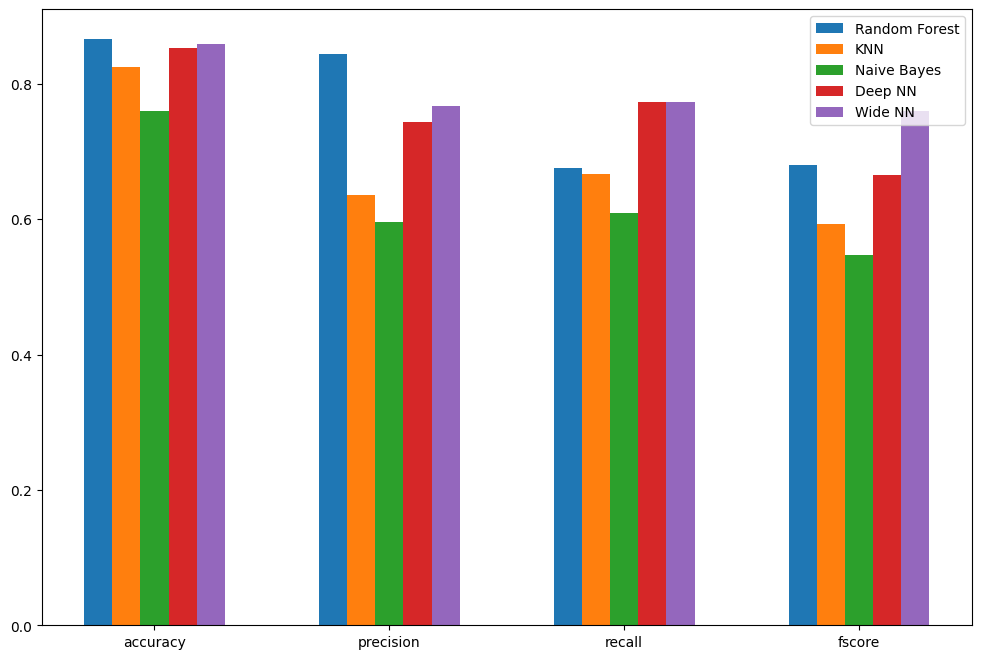

In [92]:
#Plot the 4 Confusion Matrix Metrics for each model
fig, ax = plt.subplots(figsize=(12,8))

metrics_labels = ['accuracy', 'precision', 'recall', 'fscore']
bar_width = 0.12
bar_shift= 0
index = np.arange(len(metrics_labels))

#Plot bars for each model next to each other for each metric
if RF_flag:
  ax.bar(index, random_forest_metrics, bar_width, label='Random Forest')
  bar_shift+=bar_width
if KNN_flag:
  ax.bar(index + bar_shift, knn_metrics, bar_width, label='KNN')
  bar_shift+=bar_width
if NB_flag:
  ax.bar(index + bar_shift, naive_bayes_metrics, bar_width, label='Naive Bayes')
  bar_shift+=bar_width
if DNN_flag:
  ax.bar(index + bar_shift, deep_neural_network_metrics, bar_width, label='Deep NN')
  bar_shift+=bar_width
if WNN_flag:
  ax.bar(index + bar_shift, wide_neural_network_metrics, bar_width, label='Wide NN')

#Center X-axis ticks
if bar_shift==bar_width:
  ax.set_xticks(index)
elif bar_shift%bar_width==0:
  ax.set_xticks(index + (bar_shift)/2)
else:
  ax.set_xticks(index + (bar_shift-bar_width)/2)

ax.set_xticklabels(metrics_labels)
ax.legend()

plt.show()

Classification Confusion Matrix:
945 945


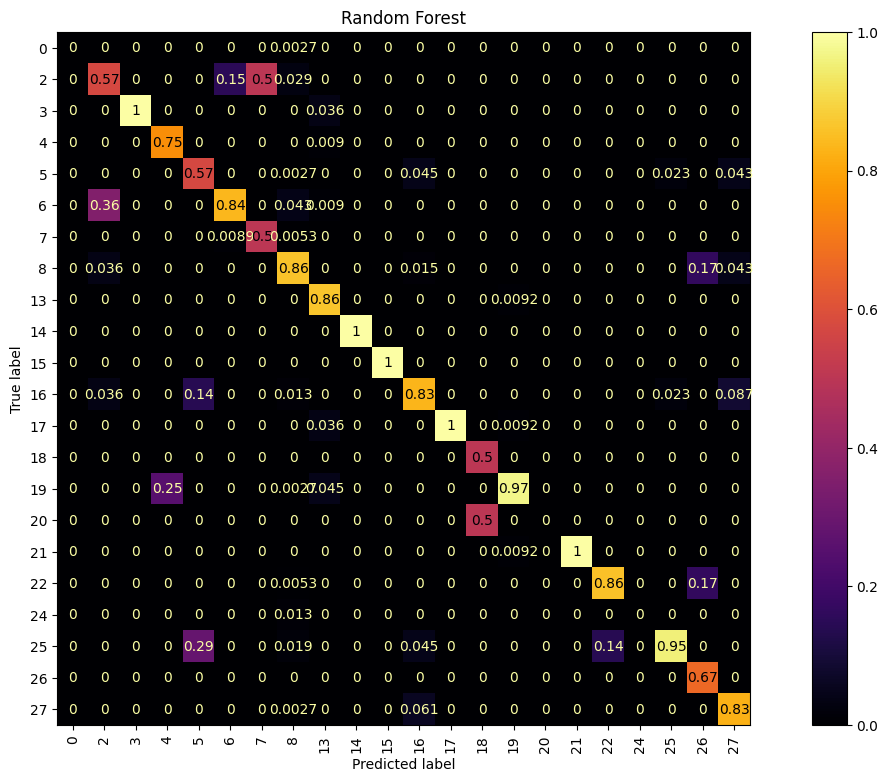

945 945


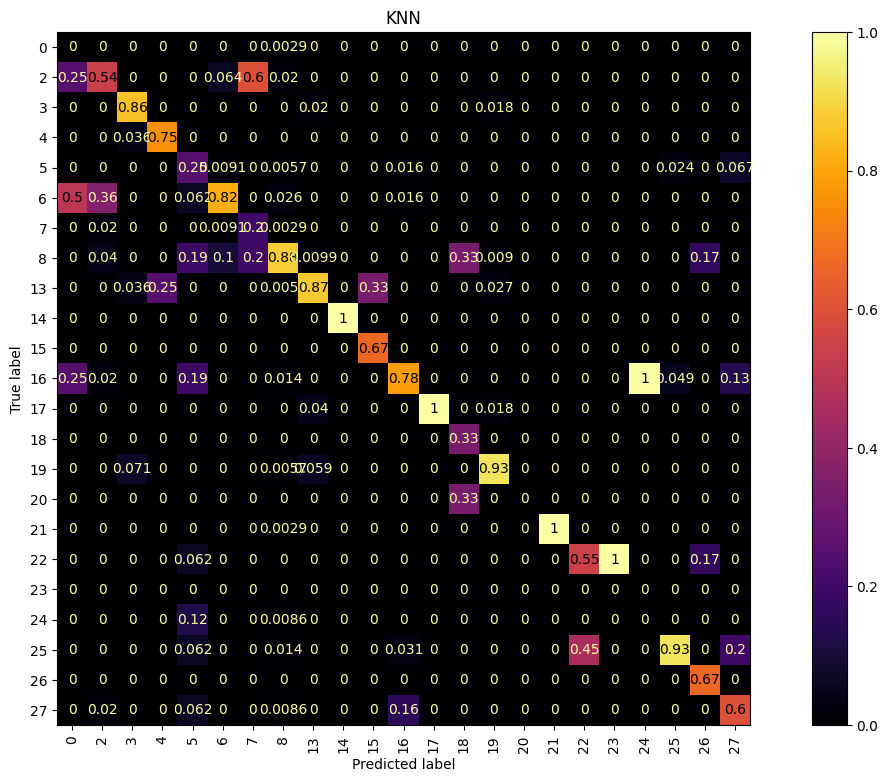

945 945


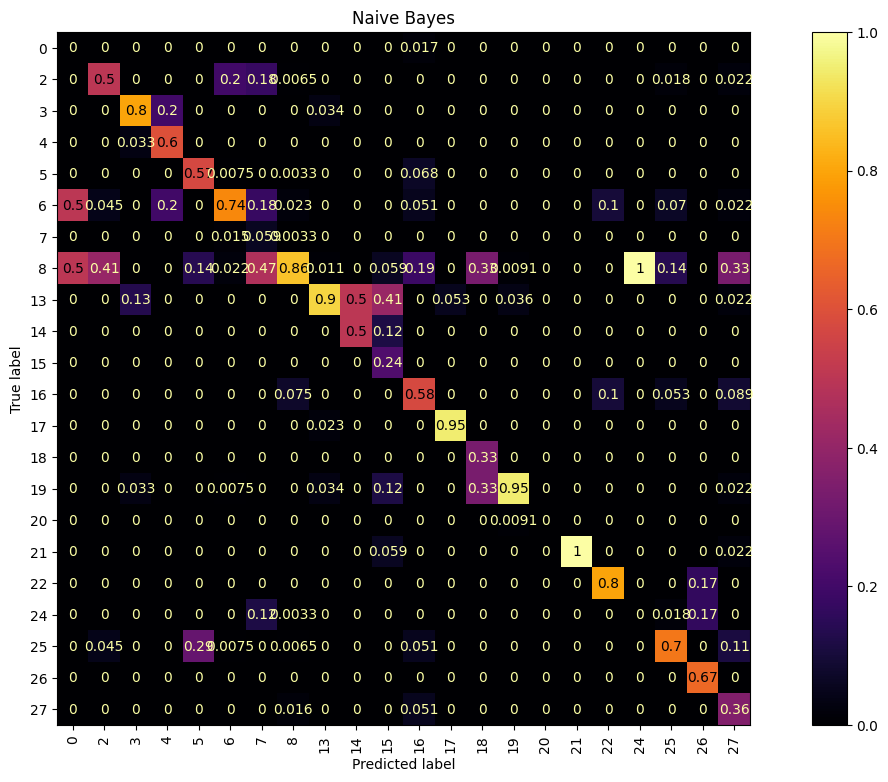

945 945


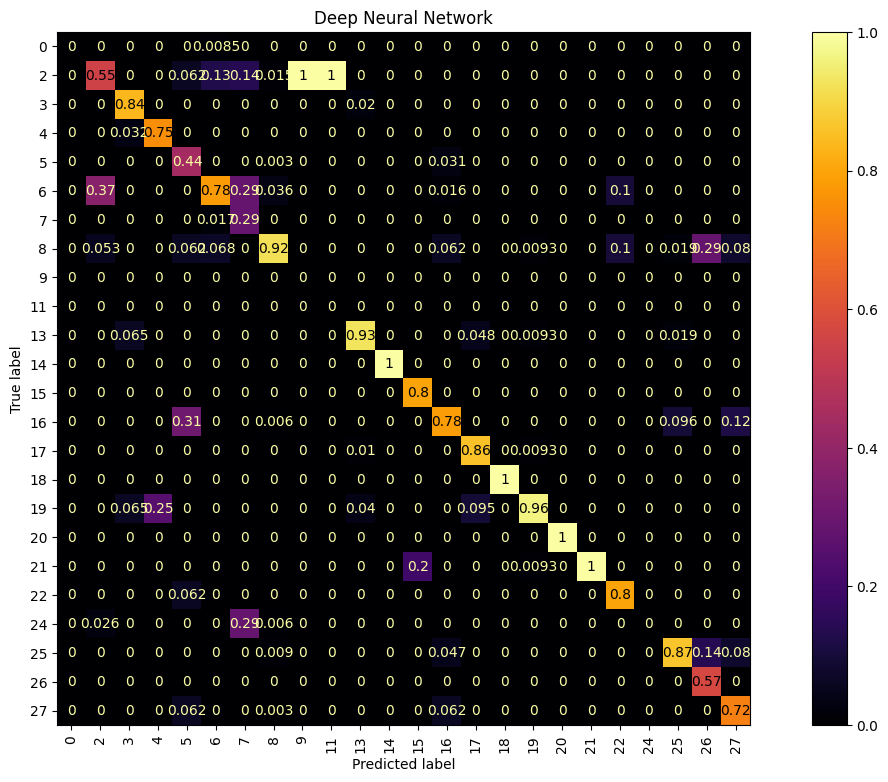

945 945


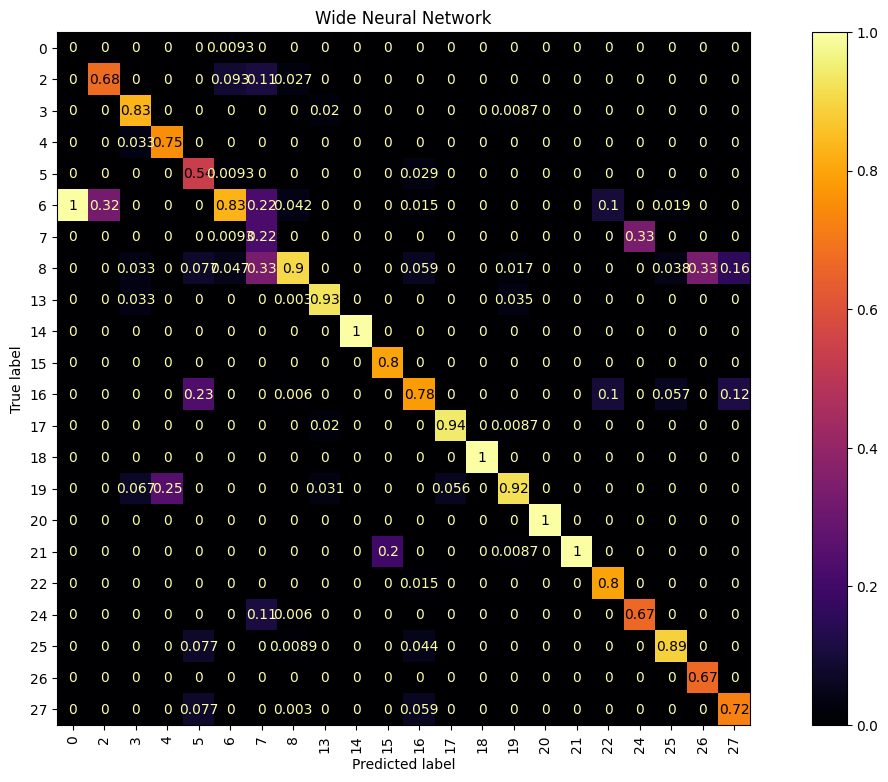

In [93]:
def plot_cm(predicted, actual, model_name):
  fig, ax = plt.subplots(figsize=(16, 9))
  print(len(actual), len(predicted))
  ConfusionMatrixDisplay.from_predictions(actual, predicted, ax=ax, normalize='pred', cmap='inferno', xticks_rotation='vertical')
  plt.title(model_name)
  plt.show()

#Plot Confusion Matrices for each model
print('Classification Confusion Matrix:')
if RF_flag:
  plot_cm(random_forest_predictions, cm_actual, "Random Forest")
if KNN_flag:
  plot_cm(knn_predictions, cm_actual, "KNN")
if NB_flag:
  plot_cm(naive_bayes_predictions, cm_actual, "Naive Bayes")
if DNN_flag:
  plot_cm(deep_neural_network_predictions, cm_actual, "Deep Neural Network")
if WNN_flag:
  plot_cm(wide_neural_network_predictions, cm_actual, "Wide Neural Network")


#Plot for Final Model Decision

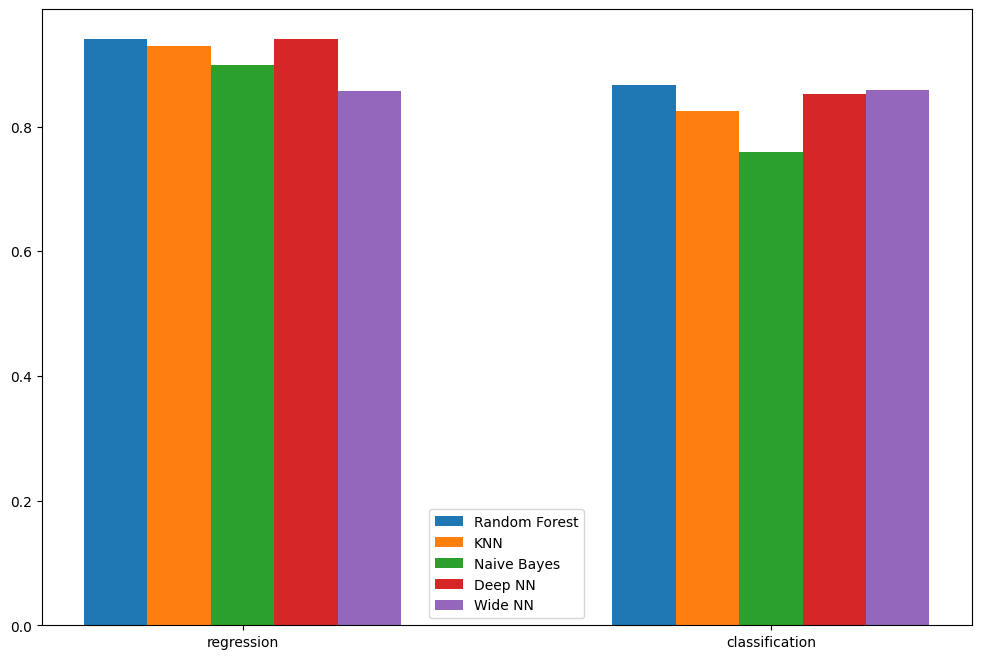

In [95]:
#Plot 1 minus Regression Prediction Error and Classification Accuracy for each model

fig, ax = plt.subplots(figsize=(12,8))

metrics_labels = ['regression', 'classification']
bar_width = 0.12
bar_shift= 0
index = np.arange(2)

#Plot metrics for each model
if RF_flag:
  ax.bar(index, (1-random_forest_error/100, random_forest_metrics[0]), bar_width, label='Random Forest')
  bar_shift+=bar_width
if KNN_flag:
  ax.bar(index + bar_shift, (1-knn_error/100, knn_metrics[0]), bar_width, label='KNN')
  bar_shift+=bar_width
if NB_flag:
  ax.bar(index + bar_shift, (1-naive_bayes_error/100, naive_bayes_metrics[0]), bar_width, label='Naive Bayes')
  bar_shift+=bar_width
if DNN_flag:
  ax.bar(index + bar_shift, (1-deep_neural_network_error/100, deep_neural_network_metrics[0]), bar_width, label='Deep NN')
  bar_shift+=bar_width
if WNN_flag:
  ax.bar(index + bar_shift, (1-wide_neural_network_error/100, wide_neural_network_metrics[0]), bar_width, label='Wide NN')

#Center X-axis ticks
if bar_shift==bar_width:
  ax.set_xticks(index)
elif bar_shift%bar_width==0:
  ax.set_xticks(index + (bar_shift)/2)
else:
  ax.set_xticks(index + (bar_shift-bar_width)/2)
ax.set_xticklabels(metrics_labels)
ax.legend()

plt.show()

#Test Results and ToDos

1.   Go Back and Clean Code and Comment Stuff
2.   Transfer to python script
3.   Write Report



In [ ]:
################### MODEL CHOICE: RANDOM FOREST ###################

test_df = pd.read_csv('/content/drive/MyDrive/Boeing Data Science Challenge Problem V2/Test_Dataset.csv').set_index('ListingID').ffill()

#Pull Out Vehicle Features
test_veh_feats = test_df['VehFeats']

#Make a new df based on the unique separate feature values from the step above
veh_feats_array = test_veh_feats.str.split(',').apply(pd.Series)
veh_feats_array[len(veh_feats_array.columns)+1] = np.zeros

#Transform Vehicle Features based on One Hot Encoder from Train and Val set
test_veh_feats = veh_one_hot.transform(veh_feats_array).toarray()

#Filter df into only useful features, not including last 2 columns as they are the label column names
test_feature_columns = useful_feature_columns[:-2]
test_df = test_df[test_feature_columns]

#Turn vehicle year into a categorical feature and not regressional
test_df['VehYear'] = test_df['VehYear'].astype(str)

#One Hot Encode String and Boolean Categorical Columns
categorical_columns = test_df.select_dtypes(include=['object', 'boolean'])
categorical_features = feat_enc.transform(categorical_columns).toarray()

test_features = get_features(test_df, categorical_features, test_veh_feats)

#Output test data predictions to a new df
output_df = pd.DataFrame()
output_df.index = test_df.index

output_df['VehTrim'] = le_lab_enc.inverse_transform(random_forest_classification.predict(test_features))
output_df['VehPrice'] = [price for price in random_forest_regression.predict(test_features)]
output_df.to_csv('/content/drive/MyDrive/Boeing Data Science Challenge Problem V2/output.csv')

#test_df_with_preds = test_df[['VehYear', 'VehMake', 'VehModel', 'VehMileage', 'VehPriceLabel']]
#test_df_with_preds['VehTrim'] = output_df['VehTrim']
#test_df_with_preds['VehPrice'] = output_df['VehPrice']
#test_df_with_preds.to_csv('/content/drive/MyDrive/Boeing Data Science Challenge Problem V2/simple_test_df_preds_DNN.csv')

<ipython-input-86-ae2cd6d32a91>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['VehYear'] = test_df['VehYear'].astype(str)


(1000, 20) (1000, 137) (6298,)
Regressional Features Shape: (1000, 3), Categorical Features Shape: (1000, 137), Vehicle Features Shape: (1000, 111), Concatenated Shape of All Features: (1000, 251)


<ipython-input-86-ae2cd6d32a91>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_with_preds['VehTrim'] = output_df['VehTrim']
<ipython-input-86-ae2cd6d32a91>:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_with_preds['VehPrice'] = output_df['VehPrice']
